# Deep Model Performance And Sub-Model Comparison

This notebook compares the saved transformer-based models on the held-out test split:

- `deep_text_only`: frozen DistilBERT text embeddings plus classifier head
- `deep_text_price`: frozen DistilBERT text embeddings plus engineered price-feature MLP fusion

The analysis mirrors the classical-model notebook so model families can be compared consistently. The StockEmotions `emo_label` and `senti_label` columns are not used as model inputs.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix, f1_score

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from marketmood.labels import LABEL_ORDER

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

PREDICTION_PATHS = {
    "text_only": PROJECT_ROOT / "outputs" / "predictions" / "deep_text_only_test_predictions.csv",
    "text_price": PROJECT_ROOT / "outputs" / "predictions" / "deep_text_price_test_predictions.csv",
}
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "deep_fusion_metrics.json"
VALIDATION_METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "deep_fusion_validation_metrics.json"
EXPERIMENT_SUMMARY_PATH = PROJECT_ROOT / "outputs" / "metrics" / "experiment_summary.csv"
PRICE_DIR = PROJECT_ROOT / "data" / "prices"

SELECTED_TICKER = "TSLA"
CHART_START = "2020-01-01"
CHART_END = "2020-03-15"

## Load Metrics And Predictions

In [2]:
with METRICS_PATH.open("r", encoding="utf-8") as file:
    deep_metrics = json.load(file)
with VALIDATION_METRICS_PATH.open("r", encoding="utf-8") as file:
    validation_metrics = json.load(file)

prediction_frames = {
    variant: pd.read_csv(path, parse_dates=["post_date", "event_date"])
    for variant, path in PREDICTION_PATHS.items()
}

for variant, frame in prediction_frames.items():
    frame["variant"] = variant
    frame["confidence"] = frame[["prob_negative", "prob_neutral", "prob_positive"]].max(axis=1)

selected_variant = "text_price"
selected_predictions = prediction_frames[selected_variant]

display(selected_predictions.head())
print({variant: frame.shape for variant, frame in prediction_frames.items()})

,id,split,ticker,post_date,event_date,original,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,variant,confidence
0,109001,test,DIS,2020-01-02,2020-01-02,$DIS when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,negative,positive,0.236887,0.307446,0.455667,text_price,0.455667
1,109002,test,AAPL,2020-01-03,2020-01-03,"$AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨",positive,positive,0.288889,0.355085,0.356027,text_price,0.356027
2,109003,test,PYPL,2020-01-07,2020-01-07,$PYPL Back Over $120+ where this belongs 💰,positive,neutral,0.316399,0.415905,0.267695,text_price,0.415905
3,100067,test,AAPL,2020-01-08,2020-01-08,$AAPL with all time highs again the market seems to enjoy war very much🤔,positive,positive,0.287762,0.316896,0.395342,text_price,0.395342
4,109005,test,BA,2020-01-08,2020-01-08,"$BA Of course there were technical problems behind this crash, just like the other two! How many more planes have to crash before this company gets banned f...",positive,neutral,0.181051,0.416894,0.402055,text_price,0.416894


{'text_only': (994, 13), 'text_price': (994, 13)}


## Deep Sub-Model Comparison

,variant,split,accuracy,macro_f1,weighted_f1,n_rows
3,text_price,test,0.652,0.624,0.653,994
1,text_only,test,0.385,0.328,0.386,994
2,text_price,validation,0.663,0.644,0.664,999
0,text_only,validation,0.363,0.316,0.357,999


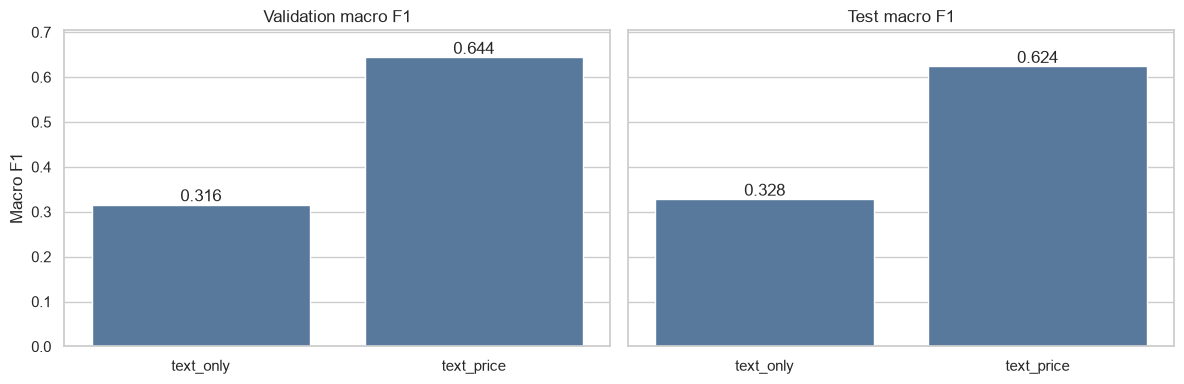

In [3]:
def _metric_row(metrics: dict, variant: str, split: str) -> dict[str, object]:
    return {
        "variant": variant,
        "split": split,
        "accuracy": metrics[variant]["accuracy"],
        "macro_f1": metrics[variant]["macro_f1"],
        "weighted_f1": metrics[variant]["weighted_f1"],
        "n_rows": metrics[variant]["n_rows"],
    }

comparison_rows = []
for variant in ["text_only", "text_price"]:
    comparison_rows.append(_metric_row(validation_metrics, variant, "validation"))
    comparison_rows.append(_metric_row(deep_metrics, variant, "test"))

comparison = pd.DataFrame(comparison_rows)
display(comparison.sort_values(["split", "macro_f1"], ascending=[True, False]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, split in zip(axes, ["validation", "test"], strict=True):
    split_data = comparison.loc[comparison["split"].eq(split)].copy()
    sns.barplot(data=split_data, x="variant", y="macro_f1", ax=axis, color="#4c78a8")
    axis.set_title(f"{split.title()} macro F1")
    axis.set_xlabel("")
    axis.set_ylabel("Macro F1")
    axis.set_ylim(0, max(0.65, split_data["macro_f1"].max() + 0.08))
    for patch in axis.patches:
        height = patch.get_height()
        axis.annotate(f"{height:.3f}", (patch.get_x() + patch.get_width() / 2, height), ha="center", va="bottom")
plt.tight_layout()

## Comparison Against Full Experiment Summary

,model,feature_set,split,accuracy,macro_f1,weighted_f1,n_rows
0,deep_text_price,text_price,test,0.652,0.624,0.653,994
1,classical_price_only,price_only,test,0.497,0.464,0.511,994
2,classical_text_price,text_price,test,0.504,0.457,0.512,994
3,technical_analysis_baseline,price_rule,test,0.476,0.412,0.475,994
4,classical_text_only,text_only,test,0.416,0.365,0.424,994
5,deep_text_only,text_only,test,0.385,0.328,0.386,994


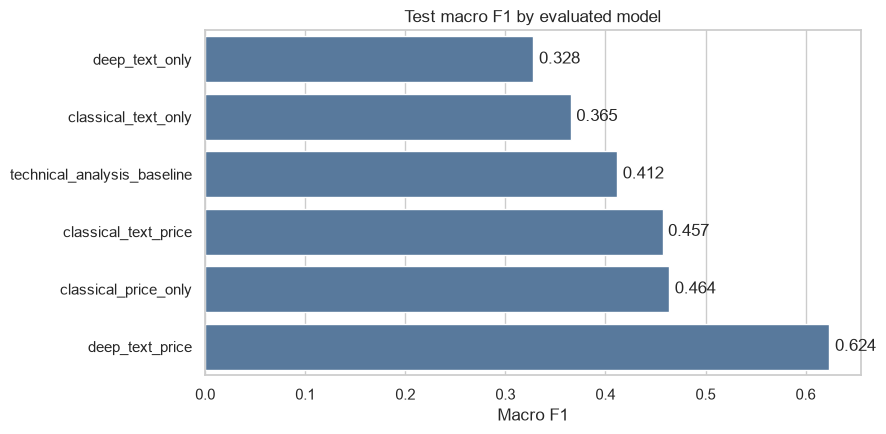

In [4]:
if EXPERIMENT_SUMMARY_PATH.exists():
    experiment_summary = pd.read_csv(EXPERIMENT_SUMMARY_PATH)
    display(experiment_summary.sort_values("macro_f1", ascending=False).round(3))

    fig, axis = plt.subplots(figsize=(9, 4.5))
    plot_data = experiment_summary.sort_values("macro_f1", ascending=True)
    sns.barplot(data=plot_data, y="model", x="macro_f1", ax=axis, color="#4c78a8")
    axis.set_title("Test macro F1 by evaluated model")
    axis.set_xlabel("Macro F1")
    axis.set_ylabel("")
    for patch in axis.patches:
        width = patch.get_width()
        axis.annotate(f"{width:.3f}", (width, patch.get_y() + patch.get_height() / 2), va="center", ha="left", xytext=(4, 0), textcoords="offset points")
    plt.tight_layout()
else:
    print("Experiment summary not found.")

## Deep Model Confusion Matrices

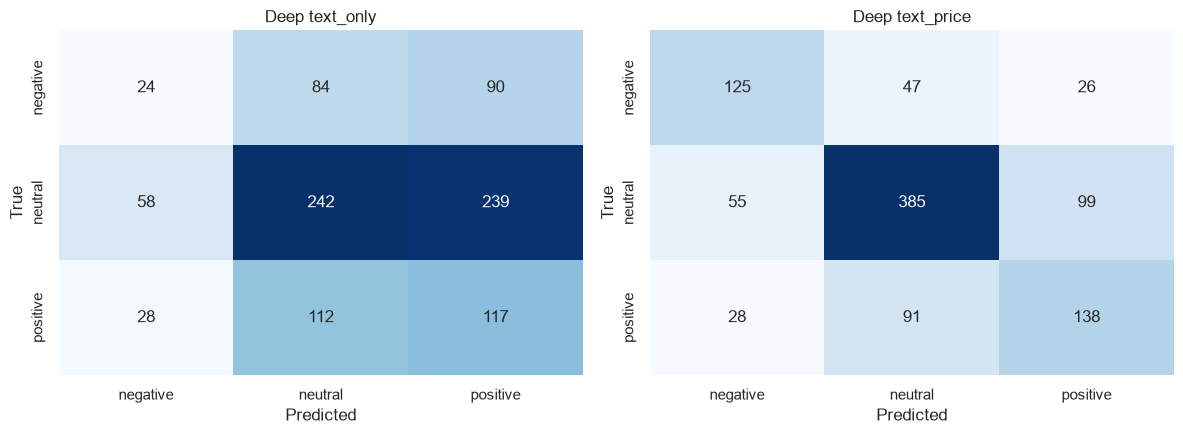

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, (variant, frame) in zip(axes, prediction_frames.items(), strict=True):
    matrix = confusion_matrix(frame["true_label"], frame["predicted_label"], labels=LABEL_ORDER)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        ax=axis,
        cbar=False,
    )
    axis.set_title(f"Deep {variant}")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")
plt.tight_layout()

## Prediction Mix And Confidence

,variant,label,true_share,predicted_share
0,text_only,negative,0.199,0.111
1,text_only,neutral,0.542,0.441
2,text_only,positive,0.259,0.449
3,text_price,negative,0.199,0.209
4,text_price,neutral,0.542,0.526
5,text_price,positive,0.259,0.265


,variant,predicted_label,rows,mean_confidence
0,text_only,negative,110,0.340
1,text_only,neutral,438,0.340
2,text_only,positive,446,0.349
3,text_price,negative,208,0.664
4,text_price,neutral,523,0.611
5,text_price,positive,263,0.582


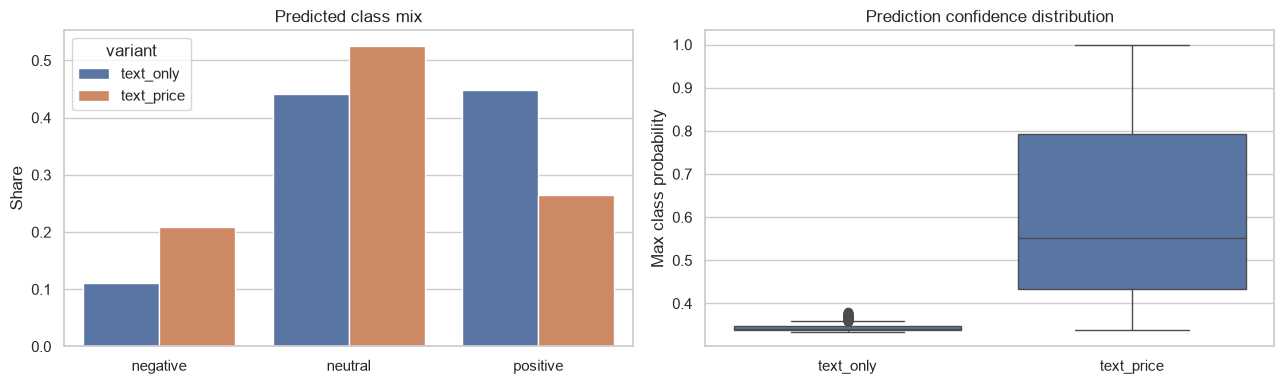

In [6]:
mix_rows = []
for variant, frame in prediction_frames.items():
    for label in LABEL_ORDER:
        mix_rows.append(
            {
                "variant": variant,
                "label": label,
                "true_share": frame["true_label"].eq(label).mean(),
                "predicted_share": frame["predicted_label"].eq(label).mean(),
            }
        )
mix = pd.DataFrame(mix_rows)
display(mix.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=mix, x="label", y="predicted_share", hue="variant", ax=axes[0])
axes[0].set_title("Predicted class mix")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share")

confidence_summary = (
    pd.concat(prediction_frames.values(), ignore_index=True)
    .groupby(["variant", "predicted_label"])
    .agg(rows=("id", "count"), mean_confidence=("confidence", "mean"))
    .reset_index()
)
display(confidence_summary.round(3))
sns.boxplot(data=pd.concat(prediction_frames.values()), x="variant", y="confidence", ax=axes[1])
axes[1].set_title("Prediction confidence distribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("Max class probability")
plt.tight_layout()

## Per-Ticker Performance

,ticker,rows,accuracy,macro_f1,predicted_positive_rate,predicted_negative_rate,mean_confidence,variant
24,TSLA,426.0,0.380,0.293,0.540,0.045,0.346,text_only
0,AAPL,167.0,0.419,0.369,0.329,0.168,0.342,text_only
2,BA,88.0,0.466,0.367,0.432,0.034,0.345,text_only
7,DIS,41.0,0.293,0.285,0.317,0.317,0.342,text_only
1,AMZN,39.0,0.333,0.251,0.462,0.128,0.345,text_only
17,MSFT,35.0,0.400,0.381,0.371,0.229,0.343,text_only
6,CCL,33.0,0.303,0.267,0.333,0.152,0.342,text_only
3,BABA,28.0,0.500,0.419,0.357,0.107,0.342,text_only
8,FB,22.0,0.182,0.151,0.545,0.136,0.343,text_only
21,PFE,20.0,0.350,0.294,0.400,0.300,0.342,text_only


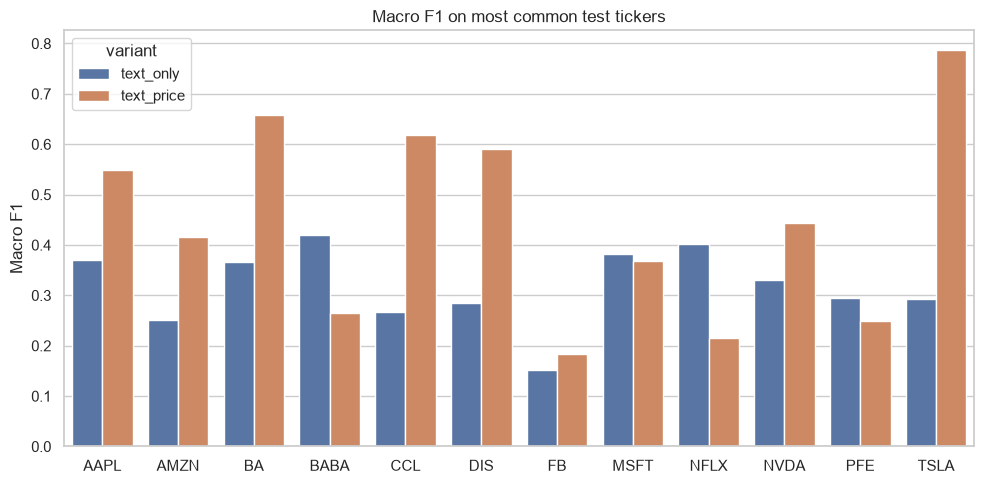

In [7]:
def ticker_macro_f1(group: pd.DataFrame) -> float:
    return f1_score(group["true_label"], group["predicted_label"], labels=LABEL_ORDER, average="macro", zero_division=0)

per_ticker_rows = []
for variant, frame in prediction_frames.items():
    ticker_summary = (
        frame.groupby("ticker")
        .apply(
            lambda group: pd.Series(
                {
                    "rows": len(group),
                    "accuracy": (group["true_label"] == group["predicted_label"]).mean(),
                    "macro_f1": ticker_macro_f1(group),
                    "predicted_positive_rate": group["predicted_label"].eq("positive").mean(),
                    "predicted_negative_rate": group["predicted_label"].eq("negative").mean(),
                    "mean_confidence": group["confidence"].mean(),
                }
            ),
            include_groups=False,
        )
        .reset_index()
    )
    ticker_summary["variant"] = variant
    per_ticker_rows.append(ticker_summary)

per_ticker = pd.concat(per_ticker_rows, ignore_index=True)
display(per_ticker.sort_values(["variant", "rows"], ascending=[True, False]).head(20).round(3))

top_tickers = selected_predictions["ticker"].value_counts().head(12).index
fig, axis = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=per_ticker.loc[per_ticker["ticker"].isin(top_tickers)],
    x="ticker",
    y="macro_f1",
    hue="variant",
    ax=axis,
)
axis.set_title("Macro F1 on most common test tickers")
axis.set_xlabel("")
axis.set_ylabel("Macro F1")
plt.tight_layout()

## Selected Stock Example

In [8]:
ticker_predictions_by_variant = {
    variant: frame.loc[frame["ticker"].eq(SELECTED_TICKER)].sort_values("event_date").copy()
    for variant, frame in prediction_frames.items()
}
selected_ticker_metrics = []
for variant, frame in ticker_predictions_by_variant.items():
    if frame.empty:
        continue
    selected_ticker_metrics.append(
        {
            "variant": variant,
            "test_rows": len(frame),
            "ticker_accuracy": (frame["true_label"] == frame["predicted_label"]).mean(),
            "ticker_macro_f1": ticker_macro_f1(frame),
            "mean_confidence": frame["confidence"].mean(),
        }
    )

selected_ticker_summary = pd.DataFrame(selected_ticker_metrics)
display(selected_ticker_summary.round(3))

,variant,test_rows,ticker_accuracy,ticker_macro_f1,mean_confidence
0,text_only,426,0.380,0.293,0.346
1,text_price,426,0.796,0.787,0.743


## Candlesticks With Deep Text + Price Predictions

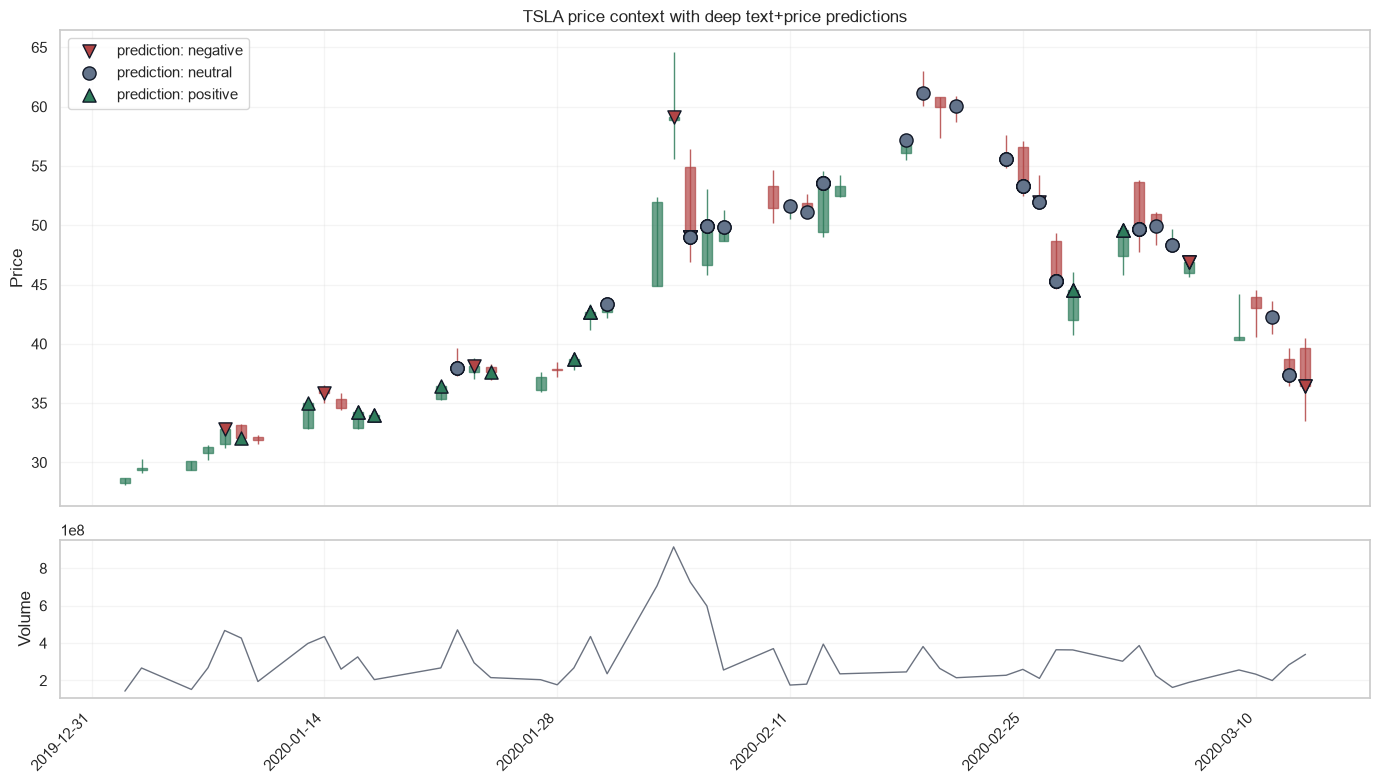

In [9]:
def load_prices(ticker: str) -> pd.DataFrame:
    price_path = PRICE_DIR / f"{ticker}.csv"
    prices = pd.read_csv(price_path, parse_dates=["date"])
    return prices.sort_values("date")

prices = load_prices(SELECTED_TICKER)
chart_prices = prices.loc[prices["date"].between(pd.Timestamp(CHART_START), pd.Timestamp(CHART_END))].copy()
chart_predictions = selected_predictions.loc[
    selected_predictions["ticker"].eq(SELECTED_TICKER)
    & selected_predictions["event_date"].between(pd.Timestamp(CHART_START), pd.Timestamp(CHART_END))
].copy()

label_colors = {"negative": "#b24545", "neutral": "#64748b", "positive": "#2f7d5c"}
label_markers = {"negative": "v", "neutral": "o", "positive": "^"}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axis = axes[0]
dates = mdates.date2num(chart_prices["date"])
for date_number, row in zip(dates, chart_prices.itertuples(index=False), strict=True):
    color = "#2f7d5c" if row.close >= row.open else "#b24545"
    axis.vlines(date_number, row.low, row.high, color=color, linewidth=1.0, alpha=0.85)
    lower = min(row.open, row.close)
    height = abs(row.close - row.open) or max(row.close * 0.001, 0.01)
    axis.add_patch(Rectangle((date_number - 0.3, lower), 0.6, height, facecolor=color, edgecolor=color, alpha=0.7))

for label in LABEL_ORDER:
    subset = chart_predictions.loc[chart_predictions["predicted_label"].eq(label)]
    merged = subset.merge(chart_prices[["date", "close"]], left_on="event_date", right_on="date", how="left")
    axis.scatter(
        merged["event_date"],
        merged["close"],
        marker=label_markers[label],
        color=label_colors[label],
        edgecolor="#111827",
        s=90,
        label=f"prediction: {label}",
        zorder=4,
    )

axis.set_title(f"{SELECTED_TICKER} price context with deep text+price predictions")
axis.set_ylabel("Price")
axis.legend(loc="upper left")
axis.grid(alpha=0.2)

axes[1].plot(chart_prices["date"], chart_prices["volume"], color="#6b7280", linewidth=1)
axes[1].set_ylabel("Volume")
axes[1].grid(alpha=0.2)
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Selected Ticker Examples

In [10]:
example_columns = [
    "event_date",
    "ticker",
    "true_label",
    "predicted_label",
    "confidence",
    "prob_negative",
    "prob_neutral",
    "prob_positive",
    "original",
]

selected_predictions.loc[selected_predictions["ticker"].eq(SELECTED_TICKER)].sort_values("event_date")[example_columns].head(20)

,event_date,ticker,true_label,predicted_label,confidence,prob_negative,prob_neutral,prob_positive,original
5,2020-01-08,TSLA,negative,negative,0.527026,0.527026,0.200570,0.272404,$TSLA I think we ready for that $510 ride Tesla. Yes we are ready. We got our seatbelts on 😂😂🔥🔥 🚀 🚀 🚀 🚀
7,2020-01-09,TSLA,neutral,positive,0.564706,0.039853,0.395441,0.564706,$TSLA the market is giving away money rn and bears refuse it. They prefer the path of greatest resistance. 🤷🏽‍♂️
13,2020-01-13,TSLA,positive,positive,0.724430,0.081660,0.193910,0.724430,$TSLA when do i buy?? Waaaaaa 😭😭
15,2020-01-14,TSLA,negative,negative,0.533508,0.533508,0.279633,0.186858,$TSLA Realistically I think ER COULD go either way.. I’m thinking of a straddle mostly bearish though because revenue could be abit low.. however straddles ...
20,2020-01-16,TSLA,neutral,positive,0.767445,0.054227,0.178328,0.767445,$TSLA you may have a gambling problem if you’re buying here. 🤷‍♂️ do as you wish
21,2020-01-16,TSLA,neutral,positive,0.621884,0.109018,0.269098,0.621884,"$TSLA who called the top here ? When everybody thought was crazy. Me moFos, me ! 🧙‍♂️"
23,2020-01-17,TSLA,positive,positive,0.600388,0.132898,0.266714,0.600388,$TSLA anyone believes it’ll hit 496$ today ??🤚🏼
24,2020-01-17,TSLA,positive,positive,0.519135,0.220952,0.259913,0.519135,$TSLA get ready to make an appointment to get in line for your appointment to fix issues Tesla owners 😳
25,2020-01-21,TSLA,positive,positive,0.492426,0.181417,0.326157,0.492426,$TSLA down 6$ afterhours right now 🤔
29,2020-01-22,TSLA,neutral,neutral,0.462437,0.198340,0.462437,0.339222,$TSLA tweet from Ross Gerber. Cool 😎 one🍷🍀🚀🤗


## Misclassification Examples And Likely Root Causes

In [11]:
def classify_deep_error(row: pd.Series) -> str:
    if row["true_label"] == row["predicted_label"]:
        return "correct"
    if row["predicted_label"] == "neutral":
        return "missed_directional_move"
    if row["true_label"] == "neutral":
        return "false_directional_prediction"
    return "opposite_direction"


def deep_root_cause(row: pd.Series) -> str:
    if row["variant"] == "text_only" and row["error_type"] == "missed_directional_move":
        return "Text-only model treated the post as routine chatter; it has no price context for the abnormal move threshold."
    if row["variant"] == "text_only":
        return "Text signal alone is weak or ambiguous for this realized return; likely hype, sarcasm, or external market news."
    if row["error_type"] == "false_directional_prediction":
        return "Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold."
    if row["error_type"] == "opposite_direction":
        return "Fusion signal pointed the wrong way; likely reversal, ticker news after the feature cutoff, or ambiguous post intent."
    return "Model confidence did not align with the generated target, likely due to noisy short-horizon movement."

all_deep_predictions = pd.concat(prediction_frames.values(), ignore_index=True)
deep_errors = all_deep_predictions.loc[
    all_deep_predictions["true_label"].ne(all_deep_predictions["predicted_label"])
].copy()
deep_errors["error_type"] = deep_errors.apply(classify_deep_error, axis=1)
deep_errors["likely_root_cause"] = deep_errors.apply(deep_root_cause, axis=1)

display(pd.crosstab([deep_errors["variant"], deep_errors["true_label"]], deep_errors["predicted_label"], margins=True))
display(deep_errors.groupby(["variant", "error_type"]).size().rename("rows").reset_index())

predicted_label        negative  neutral  positive  All
variant    true_label                                  
text_only  negative           0       84        90  174
           neutral           58        0       239  297
           positive          28      112         0  140
text_price negative           0       47        26   73
           neutral           55        0        99  154
           positive          28       91         0  119
All                         169      334       454  957

,variant,error_type,rows
0,text_only,false_directional_prediction,297
1,text_only,missed_directional_move,196
2,text_only,opposite_direction,118
3,text_price,false_directional_prediction,154
4,text_price,missed_directional_move,138
5,text_price,opposite_direction,54


In [12]:
deep_error_columns = [
    "variant",
    "ticker",
    "event_date",
    "true_label",
    "predicted_label",
    "error_type",
    "confidence",
    "prob_negative",
    "prob_neutral",
    "prob_positive",
    "likely_root_cause",
    "original",
]

representative_deep_errors = (
    deep_errors.sort_values("confidence", ascending=False)
    .groupby(["variant", "error_type"], group_keys=False)
    .head(2)[deep_error_columns]
    .reset_index(drop=True)
)
representative_deep_errors

,variant,ticker,event_date,true_label,predicted_label,error_type,confidence,prob_negative,prob_neutral,prob_positive,likely_root_cause,original
0,text_price,TSLA,2020-07-21,neutral,negative,false_directional_prediction,0.910875,0.910875,0.083401,0.005724,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.",$TSLA Imagine a it gaps up to 1700ish tomorrow before bell and then 20% run after ER.. wow that would make this to break 2K .. There we go 🚀🚀🚀
1,text_price,TSLA,2020-07-21,neutral,negative,false_directional_prediction,0.905839,0.905839,0.087087,0.007074,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.","$TSLA got shaken out @ $1,602 🤦🏻‍♂️ Sadly do not think it is wise to try and jump back in before earnings. Will be 👀 closely."
2,text_price,TSLA,2020-02-18,positive,neutral,missed_directional_move,0.845522,0.031146,0.845522,0.123332,"Model confidence did not align with the generated target, likely due to noisy short-horizon movement.","$TSLA only think that can stop our momentum, is a credit aissie downgrade that usually comes out of nowhere, if not 900+ tomorrow🤗🤗🤗🤗🤗"
3,text_price,CCL,2020-05-27,negative,neutral,missed_directional_move,0.823511,0.052892,0.823511,0.123597,"Model confidence did not align with the generated target, likely due to noisy short-horizon movement.",$CCL oh yea! Let's get another 10% day tomorrow 🤑
4,text_price,DIS,2020-03-12,positive,negative,opposite_direction,0.723648,0.723648,0.114393,0.161959,"Fusion signal pointed the wrong way; likely reversal, ticker news after the feature cutoff, or ambiguous post intent.","$DIS. When Woody contradicts Coronavirus, you gotta close the parks. 📉 Get well soon, Tom Hanks."
5,text_price,DIS,2020-03-12,positive,negative,opposite_direction,0.701150,0.701150,0.102892,0.195958,"Fusion signal pointed the wrong way; likely reversal, ticker news after the feature cutoff, or ambiguous post intent.",$DIS Bye bye Disney!! See you again at 50 👋🏼
6,text_only,TSLA,2020-12-22,neutral,positive,false_directional_prediction,0.379897,0.275204,0.344899,0.379897,"Text signal alone is weak or ambiguous for this realized return; likely hype, sarcasm, or external market news.",$TSLA This stock is overvalued. The Iranian rial is probably worth more. 😂 Tesla should make its own currency 💴 it would probably be worthless though. Elon ...
7,text_only,TSLA,2020-04-15,neutral,positive,false_directional_prediction,0.379049,0.271433,0.349518,0.379049,"Text signal alone is weak or ambiguous for this realized return; likely hype, sarcasm, or external market news.",$TSLA Ran up $80 after hours when they beat delivery reports. If they exceeded deliveries..they’re probably gonna beat earnings next week. \n\nThis stock is...
8,text_only,AAPL,2020-10-29,negative,positive,opposite_direction,0.377380,0.276897,0.345722,0.377380,"Text signal alone is weak or ambiguous for this realized return; likely hype, sarcasm, or external market news.",$AAPL Top Top Insiders at Apple 🍎 sold $29 million worth of stock at $119 to $116 highs .. before Earnings \n\nDoesn’t this concern you when TOP insiders ar...
9,text_only,TSLA,2020-02-26,negative,positive,opposite_direction,0.369595,0.280240,0.350165,0.369595,"Text signal alone is weak or ambiguous for this realized return; likely hype, sarcasm, or external market news.",$TSLA Covered at $770.00 looking for re-entry. Perhaps $780.00? 🎯✌👨‍🎓😊


In [13]:
selected_ticker_errors = deep_errors.loc[deep_errors["ticker"].eq(SELECTED_TICKER)]
selected_ticker_errors.sort_values("confidence", ascending=False)[deep_error_columns].head(12)

,variant,ticker,event_date,true_label,predicted_label,error_type,confidence,prob_negative,prob_neutral,prob_positive,likely_root_cause,original
1486,text_price,TSLA,2020-07-21,neutral,negative,false_directional_prediction,0.910875,0.910875,0.083401,0.005724,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.",$TSLA Imagine a it gaps up to 1700ish tomorrow before bell and then 20% run after ER.. wow that would make this to break 2K .. There we go 🚀🚀🚀
1485,text_price,TSLA,2020-07-21,neutral,negative,false_directional_prediction,0.905839,0.905839,0.087087,0.007074,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.","$TSLA got shaken out @ $1,602 🤦🏻‍♂️ Sadly do not think it is wise to try and jump back in before earnings. Will be 👀 closely."
1099,text_price,TSLA,2020-02-18,positive,neutral,missed_directional_move,0.845522,0.031146,0.845522,0.123332,"Model confidence did not align with the generated target, likely due to noisy short-horizon movement.","$TSLA only think that can stop our momentum, is a credit aissie downgrade that usually comes out of nowhere, if not 900+ tomorrow🤗🤗🤗🤗🤗"
1345,text_price,TSLA,2020-05-04,neutral,positive,false_directional_prediction,0.820824,0.005074,0.174102,0.820824,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.","$TSLA Elon is on Bears side 🤑🤑🤑, Bulls are in shock 🥺😳🥵"
1290,text_price,TSLA,2020-04-13,positive,neutral,missed_directional_move,0.798812,0.116666,0.798812,0.084522,"Model confidence did not align with the generated target, likely due to noisy short-horizon movement.","$TSLA its time to head 1,200$ 🚀 😎"
1014,text_price,TSLA,2020-01-16,neutral,positive,false_directional_prediction,0.767445,0.054227,0.178328,0.767445,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.",$TSLA you may have a gambling problem if you’re buying here. 🤷‍♂️ do as you wish
1300,text_price,TSLA,2020-04-16,neutral,negative,false_directional_prediction,0.766515,0.766515,0.230297,0.003188,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.","$TSLA tempted to take profit, hard with Elon’s baby 👶🏼💰"
1344,text_price,TSLA,2020-05-04,neutral,positive,false_directional_prediction,0.760050,0.006676,0.233274,0.760050,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.",$TSLA elon just tweeted tsla should be no more than 5 bucks and of story 😏 lets short and become rich
1457,text_price,TSLA,2020-07-08,neutral,positive,false_directional_prediction,0.758903,0.037944,0.203153,0.758903,"Text and prior price context resembled directional cases, but the realized next-day return stayed inside or crossed the opposite threshold.",$TSLA I sold my puts earlier sucks😎
1289,text_price,TSLA,2020-04-13,positive,neutral,missed_directional_move,0.757939,0.149717,0.757939,0.092344,"Model confidence did not align with the generated target, likely due to noisy short-horizon movement.",$TSLA wow no sellers ? Lol that’s crazy ✅


## Prediction Agreement Between Deep Sub-Models

In [14]:
agreement = prediction_frames["text_price"][["id", "ticker", "event_date", "true_label", "original"]].copy()
for variant, frame in prediction_frames.items():
    agreement = agreement.merge(
        frame[["id", "predicted_label", "confidence"]].rename(
            columns={"predicted_label": f"pred_{variant}", "confidence": f"confidence_{variant}"}
        ),
        on="id",
        how="left",
    )

agreement["deep_models_agree"] = agreement["pred_text_only"].eq(agreement["pred_text_price"])
agreement["text_price_correct"] = agreement["pred_text_price"].eq(agreement["true_label"])
agreement["text_only_correct"] = agreement["pred_text_only"].eq(agreement["true_label"])

display(agreement["deep_models_agree"].value_counts(normalize=True).rename("share").to_frame().round(3))
display(
    agreement.groupby(["deep_models_agree", "text_price_correct", "text_only_correct"])
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("rows", ascending=False)
)
agreement.loc[agreement["ticker"].eq(SELECTED_TICKER)].head(20)

,share
deep_models_agree,
False,0.594
True,0.406


,deep_models_agree,text_price_correct,text_only_correct,rows
2,False,True,False,389
4,True,True,True,259
3,True,False,False,145
1,False,False,True,124
0,False,False,False,77


,id,ticker,event_date,true_label,original,pred_text_only,confidence_text_only,pred_text_price,confidence_text_price,deep_models_agree,text_price_correct,text_only_correct
5,109004,TSLA,2020-01-08,negative,$TSLA I think we ready for that $510 ride Tesla. Yes we are ready. We got our seatbelts on 😂😂🔥🔥 🚀 🚀 🚀 🚀,positive,0.348215,negative,0.527026,False,True,False
7,109006,TSLA,2020-01-09,neutral,$TSLA the market is giving away money rn and bears refuse it. They prefer the path of greatest resistance. 🤷🏽‍♂️,positive,0.358994,positive,0.564706,True,False,False
13,109012,TSLA,2020-01-13,positive,$TSLA when do i buy?? Waaaaaa 😭😭,positive,0.350693,positive,0.724430,True,True,True
15,109013,TSLA,2020-01-14,negative,$TSLA Realistically I think ER COULD go either way.. I’m thinking of a straddle mostly bearish though because revenue could be abit low.. however straddles ...,positive,0.344820,negative,0.533508,False,True,False
20,109018,TSLA,2020-01-16,neutral,$TSLA you may have a gambling problem if you’re buying here. 🤷‍♂️ do as you wish,positive,0.361597,positive,0.767445,True,False,False
21,109019,TSLA,2020-01-16,neutral,"$TSLA who called the top here ? When everybody thought was crazy. Me moFos, me ! 🧙‍♂️",positive,0.340852,positive,0.621884,True,False,False
23,109020,TSLA,2020-01-17,positive,$TSLA anyone believes it’ll hit 496$ today ??🤚🏼,positive,0.354567,positive,0.600388,True,True,True
24,109021,TSLA,2020-01-17,positive,$TSLA get ready to make an appointment to get in line for your appointment to fix issues Tesla owners 😳,positive,0.344156,positive,0.519135,True,True,True
25,100234,TSLA,2020-01-21,positive,$TSLA down 6$ afterhours right now 🤔,negative,0.338179,positive,0.492426,False,True,False
29,109023,TSLA,2020-01-22,neutral,$TSLA tweet from Ross Gerber. Cool 😎 one🍷🍀🚀🤗,neutral,0.337202,neutral,0.462437,True,True,True
